# HW13 — Text Classification with HuggingFace Transformers

Домашняя работа: токенизация текста, инференс готовой pretrained BERT-подобной модели и базовый fine-tuning для классификации текста.

In [1]:
pip install transformers datasets accelerate scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
    set_seed as hf_set_seed,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG
# -----------------------------
SEED = 42
DATASET_NAME = "emotion"
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

BASE_DIR = Path(".")
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_PRED_PATH = ARTIFACTS_DIR / "sample_predictions.csv"
CM_PATH = ARTIFACTS_DIR / "confusion_matrix.png"

# -----------------------------
# REPRODUCIBILITY
# -----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    hf_set_seed(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Seed:", SEED)

Device: cpu
Seed: 42


In [4]:
dataset = load_dataset(DATASET_NAME)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
print("Available splits:")
for split_name in dataset.keys():
    print(split_name, len(dataset[split_name]))

Available splits:
train 16000
validation 2000
test 2000


In [6]:
label_names = dataset["train"].features["label"].names
num_labels = len(label_names)

print("Classes:", label_names)
print("Number of classes:", num_labels)

Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Number of classes: 6


In [7]:
# 3-5 примеров текстов и меток
sample_df = pd.DataFrame(dataset["train"][:5])
sample_df["label_name"] = sample_df["label"].map(lambda x: label_names[x])
display(sample_df[["text", "label", "label_name"]])

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


В этой работе используется датасет `emotion`.  
Задача — классифицировать короткий текст по одной из эмоциональных категорий.

In [8]:
# размеры split'ов
split_sizes = {k: len(v) for k, v in dataset.items()}
print("Split sizes:", split_sizes)

Split sizes: {'train': 16000, 'validation': 2000, 'test': 2000}


In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Special tokens map:", tokenizer.special_tokens_map)

Tokenizer vocab size: 30522
Special tokens map: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [10]:
token_examples = dataset["train"]["text"][:3]

for i, text in enumerate(token_examples, start=1):
    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=16,
    )

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

    print("=" * 100)
    print(f"Example {i}")
    print("Text:", text)
    print("Tokens:", tokens)
    print("Input IDs:", encoded["input_ids"])
    print("Attention mask:", encoded["attention_mask"])

Example 1
Text: i didnt feel humiliated
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Example 2
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', '[SEP]']
Input IDs: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Example 3
Text: im grabbing a minute to post i feel greedy wrong
Tokens: ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: [101, 100

In [11]:
# пример без padding/truncation и с ними
short_text = dataset["train"]["text"][0]
long_text = " ".join(dataset["train"]["text"][:10])

enc_short = tokenizer(short_text)
enc_long_trunc = tokenizer(long_text, truncation=True, padding="max_length", max_length=32)

print("Short text:")
print(short_text)
print("Tokens:", tokenizer.convert_ids_to_tokens(enc_short["input_ids"]))
print()

print("Long text with truncation + padding:")
print("Number of ids:", len(enc_long_trunc["input_ids"]))
print("Tokens:", tokenizer.convert_ids_to_tokens(enc_long_trunc["input_ids"]))
print("Attention mask:", enc_long_trunc["attention_mask"])

Short text:
i didnt feel humiliated
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']

Long text with truncation + padding:
Number of ids: 32
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', 'im', 'grabbing', 'a', 'minute', '[SEP]']
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Токенизация показывает, как текст превращается во вход модели: `input_ids` и `attention_mask`.  
Также видны special tokens и эффект `padding`/`truncation`.

In [13]:
pretrained_clf = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1,
)

inference_texts = dataset["test"]["text"][:5]
inference_true = dataset["test"]["label"][:5]

raw_inference_results = pretrained_clf(inference_texts)

rows = []
for text, true_label_id, pred in zip(inference_texts, inference_true, raw_inference_results):
    rows.append({
        "text": text,
        "true_label": label_names[true_label_id],
        "pipeline_label": pred["label"],
        "pipeline_score": pred["score"],
    })

inference_df = pd.DataFrame(rows)
display(inference_df)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,text,true_label,pipeline_label,pipeline_score
0,im feeling rather rotten so im not very ambiti...,sadness,LABEL_0,0.507409
1,im updating my blog because i feel shitty,sadness,LABEL_1,0.511243
2,i never make her separate from me because i do...,sadness,LABEL_1,0.517238
3,i left with my bouquet of red and yellow tulip...,joy,LABEL_1,0.511400
4,i was feeling a little vain when i did this one,sadness,LABEL_1,0.515184


Готовая pretrained-модель здесь запускается только как демонстрация инференса.  
Она не обучалась специально под классы датасета `emotion`, поэтому её метки и уверенность нельзя интерпретировать как корректное решение нашей прикладной задачи. Для этого нужен fine-tuning на целевом датасете.

In [14]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [15]:
# Переименуем label -> labels для Trainer
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Оставим полезные колонки
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [16]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)
model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "f1_macro": f1,
    }

In [19]:
training_args = TrainingArguments(
    output_dir=str(ARTIFACTS_DIR / "trainer_output"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [21]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.591516,0.185352,0.928000,0.902593
2,0.145567,0.157692,0.936500,0.912633


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.36854119873046876, metrics={'train_runtime': 2883.2044, 'train_samples_per_second': 11.099, 'train_steps_per_second': 0.694, 'total_flos': 389287358125632.0, 'train_loss': 0.36854119873046876, 'epoch': 2.0})

In [23]:
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation metric:", trainer.state.best_metric)
print("Best global step:", trainer.state.global_step)

Best checkpoint: artifacts\trainer_output\checkpoint-2000
Best validation metric: 0.9126325641154932
Best global step: 2000


In [25]:
test_output = trainer.predict(tokenized_dataset["test"])

test_logits = test_output.predictions
test_true = test_output.label_ids
test_pred = np.argmax(test_logits, axis=-1)

test_acc = accuracy_score(test_true, test_pred)
test_f1 = f1_score(test_true, test_pred, average="macro")

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test f1_macro: {test_f1:.4f}")

Test accuracy: 0.9225
Test f1_macro: 0.8713


Лучшая версия модели выбирается по `validation` через `load_best_model_at_end=True`.  
После этого один раз выполняется финальная оценка на `test`.

In [26]:
probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
confidences = probs.max(axis=1)

pred_label_names = [label_names[i] for i in test_pred]
true_label_names = [label_names[i] for i in test_true]

predictions_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": true_label_names,
    "pred_label": pred_label_names,
    "confidence": confidences,
})

display(predictions_df.head(10))

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.997746
1,im updating my blog because i feel shitty,sadness,sadness,0.997883
2,i never make her separate from me because i do...,sadness,sadness,0.997870
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.997757
4,i was feeling a little vain when i did this one,sadness,sadness,0.997759
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.994743
6,i felt anger when at the end of a telephone call,anger,anger,0.980875
7,i explain why i clung to a relationship with a...,joy,joy,0.613592
8,i like to have the same breathless feeling as ...,joy,joy,0.996580
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.995405


In [27]:
sample_predictions_df = predictions_df.head(20).copy()
sample_predictions_df.to_csv(SAMPLE_PRED_PATH, index=False, encoding="utf-8")

print("Saved:", SAMPLE_PRED_PATH)
display(sample_predictions_df.head(10))

Saved: artifacts\sample_predictions.csv


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.997746
1,im updating my blog because i feel shitty,sadness,sadness,0.997883
2,i never make her separate from me because i do...,sadness,sadness,0.997870
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.997757
4,i was feeling a little vain when i did this one,sadness,sadness,0.997759
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.994743
6,i felt anger when at the end of a telephone call,anger,anger,0.980875
7,i explain why i clung to a relationship with a...,joy,joy,0.613592
8,i like to have the same breathless feeling as ...,joy,joy,0.996580
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.995405


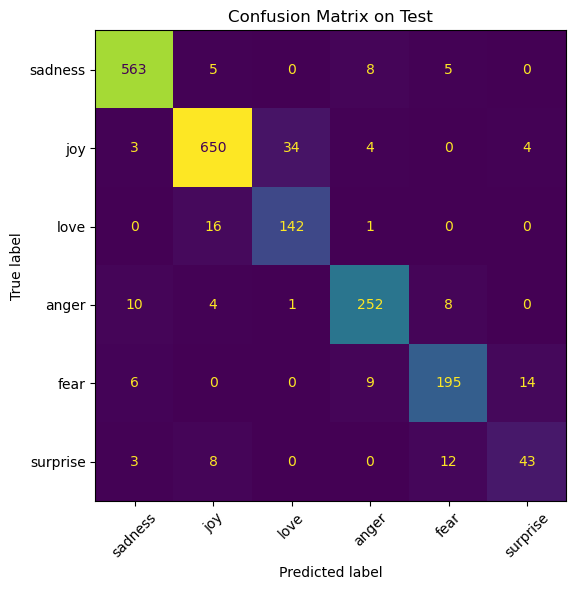

Saved: artifacts\confusion_matrix.png


In [28]:
cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix on Test")
plt.tight_layout()
plt.savefig(CM_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", CM_PATH)

In [29]:
display(predictions_df.sample(10, random_state=SEED))

,text,true_label,pred_label,confidence
1860,i feel so dirty but after spending a day at th...,sadness,sadness,0.997510
353,i could feel his breath on me and smell the sw...,joy,love,0.793641
1333,i just want to feel loved by you,love,love,0.972155
905,i have felt the need to write out my sometimes...,anger,fear,0.784174
1289,at a party i met a girl who drew me to her,anger,anger,0.656848
1273,i feel this strange sort of liberation,surprise,fear,0.735551
938,i remember feeling thrilled to use my nursing ...,joy,joy,0.997937
1731,i always feel sympathetic for those that do as...,love,love,0.985041
65,i feel a little stunned but can t imagine what...,surprise,surprise,0.975507
1323,i feel slytherin is my house slytherin is for ...,joy,surprise,0.369494


In [30]:
errors_df = predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False)

print("Number of errors on test:", len(errors_df))
display(errors_df.head(10))

Number of errors on test: 155


,text,true_label,pred_label,confidence
816,whenever i put myself in others shoes and try ...,anger,joy,0.997339
1270,i feel very saddened that the king whom i once...,joy,sadness,0.996161
1253,i don t feel betrayed coz the backstabber had ...,surprise,sadness,0.995202
1939,i don t know what to feel as in i am not sure ...,joy,sadness,0.992990
1928,i feel inside cause life is like a game someti...,fear,sadness,0.991974
426,i feel unprotected a class post count link hre...,sadness,fear,0.979606
585,i grabbed my dog and hugged her fiercly for th...,fear,sadness,0.979606
1613,i feel very cheated since i am supporting the ...,joy,sadness,0.975130
193,i really dont like quinn because i feel like s...,anger,sadness,0.970352
1206,ive come to feel about a supporting character ...,joy,love,0.969004


Краткий комментарий по ошибкам:

- часть ошибок возникает между эмоционально близкими классами;
- короткие и неоднозначные тексты сложнее классифицировать;
- высокая confidence не всегда означает корректное предсказание;
- fine-tuning заметно лучше соответствует целевой задаче, чем готовый pretrained-инференс без адаптации.

In [31]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head())
display(history_df.tail())

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.591516,1.229223,1.112222e-05,1.0,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,1000,0.185352,0.9280,0.902593,51.4807,38.849,1.224,NaN,NaN,NaN,NaN,NaN
2,0.145567,28.934494,1.111111e-08,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,2000,0.157692,0.9365,0.912633,31.0101,64.495,2.032,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,2883.2044,11.099,0.694,3.892874e+14,0.368541


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
2,0.145567,28.934494,1.111111e-08,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,2000,0.157692,0.9365,0.912633,31.0101,64.495,2.032,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,2.0,2000,NaN,NaN,NaN,NaN,NaN,NaN,2883.2044,11.099,0.694,3.892874e+14,0.368541
5,NaN,NaN,NaN,2.0,2000,0.157692,0.9365,0.912633,32.0527,62.397,1.966,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,2.0,2000,0.174326,0.9225,0.871318,39.7972,50.255,1.583,NaN,NaN,NaN,NaN,NaN


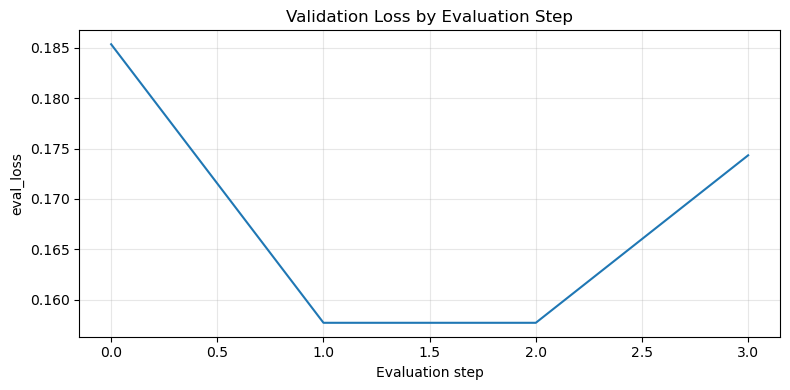

In [32]:
# График validation metrics / loss, если они есть в log_history
plot_df = history_df.copy()

if "eval_loss" in plot_df.columns:
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["eval_loss"].dropna().values)
    plt.title("Validation Loss by Evaluation Step")
    plt.xlabel("Evaluation step")
    plt.ylabel("eval_loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [33]:
print("Artifacts dir:", ARTIFACTS_DIR)
for p in ARTIFACTS_DIR.iterdir():
    print("-", p.name)

Artifacts dir: artifacts
- confusion_matrix.png
- sample_predictions.csv
- trainer_output


## Краткие выводы

- Использован датасет `emotion` для задачи многоклассовой классификации текста.
- Показан компактный разбор токенизации: токены, `input_ids`, `attention_mask`, special tokens, `padding` и `truncation`.
- Выполнен инференс готовой pretrained BERT-подобной модели на нескольких примерах.
- Проведён один основной fine-tuning `distilbert-base-uncased` для sequence classification.
- Лучшая модель выбрана по `validation`, после чего один раз выполнена финальная оценка на `test`.
- Посчитаны `accuracy` и `f1_macro`, построена матрица ошибок и сохранены примеры предсказаний.